# Baseline N3 — BAN-8 (Bilinear Attention Network)

**Référence** : Lau et al. 2018 — VQA-RAD  
**Architecture conforme au CDC** :
- Encodeur image : ResNet-50 → **grid features 14×14** (2048 × 196 tokens)
- Encodeur texte : **BERT-base-uncased** (standard, pas BiomedBERT)
- Fusion : **BAN-8** (Bilinear Attention Network, 8 têtes, ~5M params)
- Réponses : hybride CLOSED + OPEN (même modèle, deux têtes)
- Loss : **BCEWithLogitsLoss** avec soft labels (standard VQA)
- Métriques : Closed Acc., Open Acc., F1-macro, BLEU-1

**Performances attendues** : 72-76% closed / 40-45% open

## Part 1 — Installation des dépendances

In [1]:
!pip install transformers datasets torchvision sacrebleu scikit-learn -q
!pip install nltk -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 8.7 MB/s eta 0:00:00


## Part 2 — Imports & Configuration

In [2]:
# -*- coding: utf-8 -*-
"""
Baseline N3 — BAN-8 conforme CDC
Architecture : ResNet-50 grid 14x14 + BERT-base + BAN-8 + BCEWithLogitsLoss
Dataset      : VQA-RAD  |  Référence : Lau et al. 2018
"""

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.amp import autocast, GradScaler  # API stable PyTorch >= 2.0

import torchvision.models as models
import torchvision.transforms as transforms

from transformers import AutoModel, AutoTokenizer

import numpy as np
from PIL import Image
import os
import json
import random
from collections import Counter

# ─── Device & Reproductibilité ──────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device :', device)

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True

# ─── Hyperparamètres ─────────────────────────────────────────────────────────
CFG = {
    # Architecture
    'ban_heads'      : 8,        # BAN-8 conforme CDC  [INCHANGÉ]
    'img_feat_dim'   : 2048,     # ResNet-50 grid channels
    'grid_size'      : 14,       # 14×14 spatial grid
    'text_dim'       : 768,      # BERT-base hidden size
    'ban_dim'        : 1024,     # dimension interne BAN (~5M params)
    'dropout'        : 0.5,    # augmenté 0.3→0.5 (anti-overfitting)
    # Entraînement
    'batch_size'     : 32,
    'lr_head'        : 1e-3,
    'lr_encoder'     : 1e-5,
    'epochs'         : 60,    # augmenté 40→60 (plus de convergence)
    'patience'       : 10,
    'max_seq_len'    : 64,
    'img_size'       : 224,
    'label_smooth'   : 0.2,   # augmenté 0.1→0.2 (anti-overfitting)
    # Vocabulaires
    'top_closed'     : 500,      # top-N réponses fermées
    'top_open'       : 100,    # réduit 1000→100 : 483 classes pour 689 exemples était impossible
}
print('Config chargée :', CFG)

Device : cuda
Config chargée : {'ban_heads': 8, 'img_feat_dim': 2048, 'grid_size': 14, 'text_dim': 768, 'ban_dim': 1024, 'dropout': 0.5, 'batch_size': 32, 'lr_head': 0.001, 'lr_encoder': 1e-05, 'epochs': 60, 'patience': 10, 'max_seq_len': 64, 'img_size': 224, 'label_smooth': 0.2, 'top_closed': 500, 'top_open': 100}


## Part 3 — Chargement du dataset VQA-RAD

In [3]:
from google.colab import drive
drive.mount('/content/drive')

DATA_DIR  = '/content/drive/MyDrive/VQA Project/Data/VQA_RAD Image Folder'
JSON_PATH = '/content/drive/MyDrive/VQA Project/Data/VQA_RAD Dataset Public.json'

print('JSON  :', os.path.exists(JSON_PATH))
print('Images:', os.path.exists(DATA_DIR))

with open(JSON_PATH, 'r') as f:
    raw_data = json.load(f)

# Normalisation des réponses
for s in raw_data:
    s['answer']      = str(s['answer']).strip().lower()
    s['answer_type'] = s['answer_type'].strip().upper()

print(f'Total échantillons : {len(raw_data)}')
print('Exemple :', raw_data[0])

Mounted at /content/drive
JSON  : True
Images: True
Total échantillons : 2248
Exemple : {'qid': '0', 'phrase_type': 'freeform', 'qid_linked_id': '03f451ca-de62-4617-9679-e836026a7642', 'image_case_url': 'https://medpix.nlm.nih.gov/case?id=48e1dd0e-8552-46ad-a354-5eb55be86de6', 'image_name': 'synpic54610.jpg', 'image_organ': 'HEAD', 'evaluation': 'not evaluated', 'question': 'Are regions of the brain infarcted?', 'question_rephrase': 'NULL', 'question_relation': 'NULL', 'question_frame': 'NULL', 'question_type': 'PRES', 'answer': 'yes', 'answer_type': 'CLOSED'}


## Part 4 — Construction des vocabulaires (top-K answers)

In [4]:
# ─── Comptage des fréquences par type ─────────────────────────────────────
closed_counter = Counter(s['answer'] for s in raw_data if s['answer_type'] == 'CLOSED')
open_counter   = Counter(s['answer'] for s in raw_data if s['answer_type'] == 'OPEN')

# Top-K réponses (conforme CDC : 500 closed / 1000 open)
top_closed = [ans for ans, _ in closed_counter.most_common(CFG['top_closed'])]
top_open   = [ans for ans, _ in open_counter.most_common(CFG['top_open'])]

closed2idx = {a: i for i, a in enumerate(top_closed)}
open2idx   = {a: i for i, a in enumerate(top_open)}
idx2closed = {i: a for a, i in closed2idx.items()}
idx2open   = {i: a for a, i in open2idx.items()}

NUM_CLOSED = len(closed2idx)
NUM_OPEN   = len(open2idx)

# Couverture du vocabulaire
total_closed = sum(closed_counter.values())
cov_closed   = sum(closed_counter[a] for a in top_closed) / total_closed * 100
total_open   = sum(open_counter.values())
cov_open     = sum(open_counter[a] for a in top_open) / total_open * 100

print(f'Fermées  : {NUM_CLOSED} classes | couverture {cov_closed:.1f}%')
print(f'Ouvertes : {NUM_OPEN}  classes | couverture {cov_open:.1f}%')

Fermées  : 64 classes | couverture 100.0%
Ouvertes : 100  classes | couverture 45.5%


## Part 5 — Split Train / Val / Test

In [5]:
# Split officiel VQA-RAD : phrase_type distingue train/test
train_full = [s for s in raw_data if s['phrase_type'] in ('para', 'freeform')]
test_data  = [s for s in raw_data if s['phrase_type'] in ('test_para', 'test_freeform')]

# Filtrer uniquement les réponses dans le vocabulaire top-K
def in_vocab(s):
    if s['answer_type'] == 'CLOSED':
        return s['answer'] in closed2idx
    else:
        return s['answer'] in open2idx

train_full = [s for s in train_full if in_vocab(s)]
test_data  = [s for s in test_data  if in_vocab(s)]

# 90/10 split pour validation
random.shuffle(train_full)
split     = int(0.9 * len(train_full))
train_data = train_full[:split]
val_data   = train_full[split:]

print(f'Train : {len(train_data)} | Val : {len(val_data)} | Test : {len(test_data)}')

# Distribution par type
for name, ds in [('Train', train_data), ('Val', val_data), ('Test', test_data)]:
    c = sum(1 for s in ds if s['answer_type'] == 'CLOSED')
    o = sum(1 for s in ds if s['answer_type'] == 'OPEN')
    print(f'  {name} → CLOSED:{c} | OPEN:{o}')

Train : 1238 | Val : 138 | Test : 355
  Train → CLOSED:914 | OPEN:324
  Val → CLOSED:113 | OPEN:25
  Test → CLOSED:272 | OPEN:83


## Part 6 — Dataset & Transforms

In [6]:
# ─── Transforms ──────────────────────────────────────────────────────────────
# Standard VQA-RAD / ImageNet normalization
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD),
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD),
])


# ─── Dataset ─────────────────────────────────────────────────────────────────
class VQARADDataset(Dataset):
    def __init__(self, data, image_dir, transform, closed2idx, open2idx):
        self.data       = data
        self.image_dir  = image_dir
        self.transform  = transform
        self.c2i        = closed2idx
        self.o2i        = open2idx

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        s         = self.data[idx]
        img_path  = os.path.join(self.image_dir, s['image_name'])
        image     = Image.open(img_path).convert('RGB')
        image     = self.transform(image)

        question     = s['question']
        is_closed    = (s['answer_type'] == 'CLOSED')
        answer_type  = 0 if is_closed else 1
        label        = self.c2i[s['answer']] if is_closed else self.o2i[s['answer']]
        qtype        = s.get('question_type', 'OTHER')

        return image, question, answer_type, label, qtype


print('Dataset class définie.')

Dataset class définie.


## Part 7 — Tokenizer BERT-base (conforme CDC N3)

In [7]:
# CDC Baseline N3 spécifie BERT-base (pas BiomedBERT — réservé au N5 fusionné)
BERT_NAME = 'bert-base-uncased'
tokenizer = AutoTokenizer.from_pretrained(BERT_NAME)
print(f'Tokenizer chargé : {BERT_NAME}')


# ─── Collate function ────────────────────────────────────────────────────────
def collate_fn(batch):
    images, questions, ans_types, labels, qtypes = zip(*batch)
    images    = torch.stack(images)
    tokens    = tokenizer(
        list(questions),
        padding       = True,
        truncation    = True,
        max_length    = CFG['max_seq_len'],
        return_tensors= 'pt'
    )
    ans_types = torch.tensor(ans_types, dtype=torch.long)
    labels    = torch.tensor(labels,    dtype=torch.long)
    return images, tokens['input_ids'], tokens['attention_mask'], ans_types, labels, list(qtypes)


# ─── DataLoaders ─────────────────────────────────────────────────────────────
train_dataset = VQARADDataset(train_data, DATA_DIR, train_transform, closed2idx, open2idx)
val_dataset   = VQARADDataset(val_data,   DATA_DIR, val_transform,   closed2idx, open2idx)
test_dataset  = VQARADDataset(test_data,  DATA_DIR, val_transform,   closed2idx, open2idx)

train_loader = DataLoader(train_dataset, batch_size=CFG['batch_size'],
                          shuffle=True,  collate_fn=collate_fn, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=CFG['batch_size'],
                          shuffle=False, collate_fn=collate_fn, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=CFG['batch_size'],
                          shuffle=False, collate_fn=collate_fn, num_workers=2)

print(f'Train batches : {len(train_loader)}')
print(f'Val   batches : {len(val_loader)}')
print(f'Test  batches : {len(test_loader)}')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizer chargé : bert-base-uncased
Train batches : 39
Val   batches : 5
Test  batches : 12


## Part 8 — Architecture BAN-8

### Détail technique conforme CDC
- **Image encoder** : ResNet-50 tronqué avant avgpool → feature map spatiale **(B, 2048, 14, 14)** → reshape → **(B, 196, 2048)** → projection → **(B, 196, ban_dim)**
- **Text encoder** : BERT-base → séquence complète **(B, L, 768)** → projection → **(B, L, ban_dim)**
- **BAN-8** : 8 têtes bilinéaires, chaque tête calcule une attention entre chaque token visuel et chaque token textuel → **(B, ban_dim)**
- **Têtes de réponse** : deux FC parallèles, prédiction routée par `answer_type`
- **Loss** : `BCEWithLogitsLoss` avec soft labels (standard VQA)

In [8]:
# =============================================================================
# 8.1 — Encodeur Visuel : ResNet-50 → grid 14×14
# =============================================================================
class ImageEncoder(nn.Module):
    """
    ResNet-50 → grid features 14×14 (196 tokens visuels).
    Conforme CDC N3 et Lau et al. 2018.

    Calcul des dimensions pour input 224×224 :
      stem                        : 224 → 56
      layer1 (stride=1)           : 56  → 56
      layer2 (stride=2)           : 56  → 28
      layer3 (stride=2, GARDÉ)    : 28  → 14  ← ne pas modifier
      layer4 (stride=2, SUPPRIMÉ) : 14  → 14  ← seulement ici
    Sortie CNN : (B, 2048, 14, 14)
    Sortie proj : (B, 196, out_dim)

    ERREUR CORRIGÉE : l'ancienne version modifiait layer3 ET layer4
    ce qui produisait un grid 28×28 (784 tokens) au lieu de 14×14.
    """
    def __init__(self, out_dim: int = 1024):
        super().__init__()
        resnet = models.resnet50(weights='IMAGENET1K_V1')

        # ── Supprimer le stride de layer4 SEULEMENT ─────────────────────
        # layer3 garde son stride=2 : 28→14
        # layer4 perd son stride=2  : 14→14  (dilation pour garder le champ réceptif)
        resnet.layer4[0].conv2.stride         = (1, 1)
        resnet.layer4[0].downsample[0].stride = (1, 1)
        # Résultat : (B, 2048, 14, 14) ✓

        self.cnn  = nn.Sequential(*list(resnet.children())[:-2])
        self.proj = nn.Sequential(
            nn.Linear(2048, out_dim),
            nn.ReLU(),
            nn.Dropout(CFG['dropout']),
        )

    def forward(self, x):
        # x : (B, 3, 224, 224)
        f = self.cnn(x)               # (B, 2048, 14, 14)
        B, C, H, W = f.shape
        assert H == 14 and W == 14, f"Grid inattendu : {H}×{W} (attendu 14×14)"
        f = f.view(B, C, H * W)       # (B, 2048, 196)
        f = f.permute(0, 2, 1)        # (B, 196, 2048)
        return self.proj(f)            # (B, 196, out_dim)


# =============================================================================
# 8.2 — Encodeur Textuel : BERT-base
# =============================================================================
class TextEncoder(nn.Module):
    """
    BERT-base → séquence complète de tokens (pas seulement [CLS])
    Sortie : (B, L, ban_dim)
    """
    def __init__(self, out_dim: int = 1024):
        super().__init__()
        self.bert = AutoModel.from_pretrained(BERT_NAME)
        self.proj = nn.Sequential(
            nn.Linear(768, out_dim),
            nn.ReLU(),
            nn.Dropout(CFG['dropout']),
        )

    def forward(self, input_ids, attention_mask):
        out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        seq = out.last_hidden_state   # (B, L, 768)
        return self.proj(seq)          # (B, L, ban_dim)


# =============================================================================
# 8.3 — BAN-8 : Bilinear Attention Network à 8 têtes
# =============================================================================
class BAN8(nn.Module):
    """
    Bilinear Attention Network avec h=8 têtes.
    Référence : Kim & Mooney, NeurIPS 2018.

    Pour chaque tête h :
      - W_v^h, W_q^h projettent V et Q dans un espace commun d
      - Attention bilinéaire : A_h = softmax((V W_v^h) ⊙ (Q W_q^h) / sqrt(d))
      - Contexte : c_h = A_h^T V W_v^h  (weighted sum of visual tokens)
    Sortie : moyenne des 8 contextes → (B, ban_dim)

    Paramètres ≈ 8 × 2 × (ban_dim × ban_dim/8) = 2 × ban_dim²  ≈ 2M pour ban_dim=1024
    """
    def __init__(self, v_dim: int, q_dim: int, ban_dim: int, num_heads: int = 8):
        super().__init__()
        assert ban_dim % num_heads == 0, 'ban_dim doit être divisible par num_heads'
        self.h       = num_heads
        self.d       = ban_dim // num_heads    # dimension par tête
        self.ban_dim = ban_dim

        # Projections linéaires : une par tête, sur les features visuelles et textuelles
        self.W_v = nn.ModuleList([nn.Linear(v_dim,  self.d, bias=False) for _ in range(num_heads)])
        self.W_q = nn.ModuleList([nn.Linear(q_dim,  self.d, bias=False) for _ in range(num_heads)])

        # Projection de sortie : concaténation des h contextes → ban_dim
        self.out_proj = nn.Sequential(
            nn.Linear(ban_dim, ban_dim),
            nn.ReLU(),
            nn.Dropout(CFG['dropout']),
        )
        self.scale = self.d ** -0.5

    def forward(self, v, q):
        """
        v : (B, Nv, v_dim)  — tokens visuels  (196 patches)
        q : (B, Nq, q_dim)  — tokens textuels (séquence BERT)
        Retourne : (B, ban_dim), (B, h, Nv, Nq) attention maps
        """
        B, Nv, _ = v.shape
        _, Nq, _ = q.shape

        head_contexts = []
        attention_maps = []

        for h_idx in range(self.h):
            v_h = self.W_v[h_idx](v)   # (B, Nv, d)
            q_h = self.W_q[h_idx](q)   # (B, Nq, d)

            # Attention bilinéaire : (B, Nv, Nq)
            # A[b, i, j] = dot(v_h[b,i], q_h[b,j]) / sqrt(d)
            attn = torch.bmm(v_h, q_h.transpose(1, 2)) * self.scale  # (B, Nv, Nq)
            attn = F.softmax(attn, dim=2)                              # softmax sur Nq
            attention_maps.append(attn)                                # (B, Nv, Nq)

            # Contexte : somme pondérée des features textuelles pour chaque pixel visuel
            # → (B, Nv, d), puis moyenne sur les pixels
            ctx = torch.bmm(attn, q_h)          # (B, Nv, d)
            ctx = (ctx * v_h).sum(dim=1)         # (B, d)  — élément-par-élément + réduction
            head_contexts.append(ctx)

        # Concaténation des h=8 contextes : (B, h*d) = (B, ban_dim)
        fused = torch.cat(head_contexts, dim=-1)  # (B, ban_dim)
        fused = self.out_proj(fused)               # (B, ban_dim)

        attn_stack = torch.stack(attention_maps, dim=1)  # (B, h, Nv, Nq)
        return fused, attn_stack


# =============================================================================
# 8.4 — Modèle complet MedVQA N3
# =============================================================================
class MedVQA_N3_BAN8(nn.Module):
    """
    Pipeline complet Baseline N3 :
      image  → ImageEncoder → (B, 196, ban_dim)
      question → TextEncoder → (B, L,   ban_dim)
      BAN-8  → fusion        → (B, ban_dim)
      head_closed / head_open → logits
    """
    def __init__(self, num_closed: int, num_open: int, ban_dim: int = 1024):
        super().__init__()
        self.img_enc    = ImageEncoder(out_dim=ban_dim)
        self.txt_enc    = TextEncoder(out_dim=ban_dim)
        self.ban        = BAN8(v_dim=ban_dim, q_dim=ban_dim,
                               ban_dim=ban_dim, num_heads=CFG['ban_heads'])

        # Têtes de classification parallèles
        self.head_closed = nn.Sequential(
            nn.Linear(ban_dim, ban_dim // 2),
            nn.ReLU(),
            nn.Dropout(CFG['dropout']),
            nn.Linear(ban_dim // 2, num_closed),
        )
        self.head_open = nn.Sequential(
            nn.Linear(ban_dim, ban_dim // 2),
            nn.ReLU(),
            nn.Dropout(CFG['dropout']),
            nn.Linear(ban_dim // 2, num_open),
        )

    def forward(self, img, input_ids, attn_mask):
        v    = self.img_enc(img)                     # (B, 196, ban_dim)
        q    = self.txt_enc(input_ids, attn_mask)    # (B, L,   ban_dim)
        fused, attn_maps = self.ban(v, q)            # (B, ban_dim)

        logits_closed = self.head_closed(fused)      # (B, num_closed)
        logits_open   = self.head_open(fused)        # (B, num_open)
        return logits_closed, logits_open, attn_maps


# ─── Instanciation & compte des paramètres ───────────────────────────────────
model = MedVQA_N3_BAN8(
    num_closed = NUM_CLOSED,
    num_open   = NUM_OPEN,
    ban_dim    = CFG['ban_dim']
).to(device)

total_params = sum(p.numel() for p in model.parameters())
train_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
ban_params   = sum(p.numel() for p in model.ban.parameters())
print(f'Paramètres totaux       : {total_params:,}')
print(f'Paramètres entraînables : {train_params:,}')
print(f'Paramètres BAN-8        : {ban_params:,}')

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 187MB/s]


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Paramètres totaux       : 140,156,388
Paramètres entraînables : 140,156,388
Paramètres BAN-8        : 3,146,752


## Part 9 — Loss & Soft Labels (BCEWithLogitsLoss — standard VQA)

**Pourquoi BCE et pas CrossEntropy ?**  
Le CDC spécifie `BCEWithLogitsLoss` car le standard VQA utilise des **soft labels** :
chaque réponse reçoit un score ∈ [0,1] basé sur la fréquence d'annotation humaine.
Avec `CrossEntropy`, on force un one-hot dur qui sous-estime l'ambiguïté médicale.

In [9]:
def make_soft_labels(labels, num_classes, smoothing=0.1):
    """
    Construit des soft labels one-hot avec label smoothing.
    target[i, labels[i]] = 1 - smoothing
    target[i, j≠labels[i]] = smoothing / (num_classes - 1)
    """
    B = labels.size(0)
    soft = torch.full((B, num_classes), smoothing / (num_classes - 1),
                      device=labels.device, dtype=torch.float)
    soft.scatter_(1, labels.unsqueeze(1), 1.0 - smoothing)
    return soft


bce_criterion = nn.BCEWithLogitsLoss(reduction='mean')

def compute_loss(logits_closed, logits_open, labels, ans_types):
    """
    Calcule la loss BCE séparément pour CLOSED et OPEN
    puis fait la moyenne pondérée.
    """
    mask_c = (ans_types == 0)
    mask_o = (ans_types == 1)

    loss = torch.tensor(0.0, device=logits_closed.device)

    if mask_c.any():
        soft_c = make_soft_labels(labels[mask_c], NUM_CLOSED, CFG['label_smooth'])
        loss   = loss + bce_criterion(logits_closed[mask_c], soft_c)

    if mask_o.any():
        soft_o = make_soft_labels(labels[mask_o], NUM_OPEN, CFG['label_smooth'])
        # Poids ×2 sur OPEN : compense le déséquilibre CLOSED>>OPEN
        # et force le modèle à apprendre les questions ouvertes
        loss   = loss + 2.0 * bce_criterion(logits_open[mask_o], soft_o)

    # Normalisation : si les deux types présents dans le batch
    # facteur 3.0 car CLOSED×1 + OPEN×2 = 3 parts au total
    if mask_c.any() and mask_o.any():
        loss = loss / 3.0

    return loss


print('BCEWithLogitsLoss + soft labels configurée.')

BCEWithLogitsLoss + soft labels configurée.


## Part 10 — Optimizer & Scheduler (3 phases de fine-tuning)

In [10]:
def build_optimizer(model, phase=1):
    """
    Phase 1 (epochs 0-4) : encodeurs gelés, on n'entraîne que BAN + têtes
    Phase 2 (epochs 5+)  : on dégèle tout avec LR discriminatif
    """
    if phase == 1:
        # Geler les encodeurs
        for p in model.img_enc.cnn.parameters():
            p.requires_grad = False
        for p in model.txt_enc.bert.parameters():
            p.requires_grad = False

        param_groups = [
            {'params': model.img_enc.proj.parameters(),  'lr': CFG['lr_head']},
            {'params': model.txt_enc.proj.parameters(),  'lr': CFG['lr_head']},
            {'params': model.ban.parameters(),            'lr': CFG['lr_head']},
            {'params': model.head_closed.parameters(),   'lr': CFG['lr_head']},
            {'params': model.head_open.parameters(),     'lr': CFG['lr_head']},
        ]
    else:
        # Dégeler tout
        for p in model.parameters():
            p.requires_grad = True

        param_groups = [
            {'params': model.img_enc.cnn.parameters(),   'lr': CFG['lr_encoder']},
            {'params': model.img_enc.proj.parameters(),  'lr': CFG['lr_head']},
            {'params': model.txt_enc.bert.parameters(),  'lr': CFG['lr_encoder']},
            {'params': model.txt_enc.proj.parameters(),  'lr': CFG['lr_head']},
            {'params': model.ban.parameters(),            'lr': CFG['lr_head']},
            {'params': model.head_closed.parameters(),   'lr': CFG['lr_head']},
            {'params': model.head_open.parameters(),     'lr': CFG['lr_head']},
        ]

    optimizer = torch.optim.AdamW(param_groups, weight_decay=5e-2)  # augmenté 1e-2→5e-2 (anti-overfitting)
    return optimizer


print('Optimizer builder défini.')

Optimizer builder défini.


## Part 11 — Boucle d'entraînement complète

In [11]:
def evaluate(model, loader):
    """
    Calcule accuracy CLOSED, OPEN et globale sur un DataLoader.
    Retourne aussi les prédictions pour les métriques finales.
    """
    model.eval()
    correct_c, total_c = 0, 0
    correct_o, total_o = 0, 0

    with torch.no_grad():
        for imgs, input_ids, attn_mask, ans_types, labels, _ in loader:
            imgs      = imgs.to(device)
            input_ids = input_ids.to(device)
            attn_mask = attn_mask.to(device)
            labels    = labels.to(device)
            ans_types = ans_types.to(device)

            logits_c, logits_o, _ = model(imgs, input_ids, attn_mask)

            mask_c = (ans_types == 0)
            mask_o = (ans_types == 1)

            if mask_c.any():
                preds_c    = logits_c[mask_c].argmax(dim=1)
                correct_c += (preds_c == labels[mask_c]).sum().item()
                total_c   += mask_c.sum().item()

            if mask_o.any():
                preds_o    = logits_o[mask_o].argmax(dim=1)
                correct_o += (preds_o == labels[mask_o]).sum().item()
                total_o   += mask_o.sum().item()

    acc_c = 100 * correct_c / total_c if total_c > 0 else 0.0
    acc_o = 100 * correct_o / total_o if total_o > 0 else 0.0
    return acc_c, acc_o


def train_model(model, train_loader, val_loader,
                epochs=40, patience=10, freeze_epochs=5,
                checkpoint='best_n3_ban8.pth'):

    scaler          = GradScaler('cuda')  # Fix FutureWarning
    optimizer       = build_optimizer(model, phase=1)
    scheduler       = torch.optim.lr_scheduler.ReduceLROnPlateau(
                        optimizer, mode='max', factor=0.5, patience=4)

    best_val_combined = 0.0
    epochs_no_improve = 0
    history           = []

    print('=' * 70)
    print(f'  Baseline N3 — BAN-8 | {epochs} epochs | patience={patience}')
    print('=' * 70)
    print(f'  Phase 1 : encodeurs GELÉS (epochs 1-{freeze_epochs})')

    for epoch in range(epochs):

        # ── Changement de phase ─────────────────────────────────────────────
        if epoch == freeze_epochs:
            print(f'\n  >>> Phase 2 : DÉGEL encodeurs (epoch {epoch+1}) <<<')
            optimizer = build_optimizer(model, phase=2)
            # Warmup 2 epochs après dégel : évite la remontée de loss
            # LinearLR : LR part de 10% et monte à 100% en 2 epochs
            # puis CosineAnnealingLR prend le relais
            warmup_sched = torch.optim.lr_scheduler.LinearLR(
                            optimizer, start_factor=0.1, total_iters=2)
            cosine_sched = torch.optim.lr_scheduler.CosineAnnealingLR(
                            optimizer,
                            T_max=epochs - freeze_epochs - 2,
                            eta_min=1e-6)
            scheduler = torch.optim.lr_scheduler.SequentialLR(
                            optimizer,
                            schedulers=[warmup_sched, cosine_sched],
                            milestones=[2])

        model.train()
        total_loss = 0.0
        correct_c, total_c = 0, 0
        correct_o, total_o = 0, 0

        for batch in train_loader:
            imgs, input_ids, attn_mask, ans_types, labels, _ = batch
            imgs      = imgs.to(device)
            input_ids = input_ids.to(device)
            attn_mask = attn_mask.to(device)
            ans_types = ans_types.to(device)
            labels    = labels.to(device)

            optimizer.zero_grad()

            with autocast('cuda'):  # Fix FutureWarning
                logits_c, logits_o, _ = model(imgs, input_ids, attn_mask)
                loss = compute_loss(logits_c, logits_o, labels, ans_types)

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()

            total_loss += loss.item()

            # Accuracy batch
            with torch.no_grad():
                mask_c = (ans_types == 0)
                mask_o = (ans_types == 1)
                if mask_c.any():
                    correct_c += (logits_c[mask_c].argmax(1) == labels[mask_c]).sum().item()
                    total_c   += mask_c.sum().item()
                if mask_o.any():
                    correct_o += (logits_o[mask_o].argmax(1) == labels[mask_o]).sum().item()
                    total_o   += mask_o.sum().item()

        # ── Validation ─────────────────────────────────────────────────────
        val_acc_c, val_acc_o = evaluate(model, val_loader)
        val_combined = (val_acc_c + val_acc_o) / 2.0

        train_acc_c = 100 * correct_c / total_c if total_c > 0 else 0.0
        train_acc_o = 100 * correct_o / total_o if total_o > 0 else 0.0
        avg_loss    = total_loss / len(train_loader)

        if epoch >= freeze_epochs:
            scheduler.step()  # SequentialLR/CosineAnnealingLR : pas d'argument

        # ── Early stopping & checkpoint ────────────────────────────────────
        saved = ''
        if val_combined > best_val_combined:
            best_val_combined = val_combined
            epochs_no_improve = 0
            torch.save({
                'epoch'           : epoch,
                'model_state_dict': model.state_dict(),
                'val_acc_closed'  : val_acc_c,
                'val_acc_open'    : val_acc_o,
                'val_combined'    : val_combined,
                'num_closed'      : NUM_CLOSED,
                'num_open'        : NUM_OPEN,
                'ban_dim'         : CFG['ban_dim'],
            }, checkpoint)
            saved = ' ✓ SAVED'
        else:
            epochs_no_improve += 1

        history.append({
            'epoch': epoch + 1,
            'loss' : avg_loss,
            'train_closed': train_acc_c,
            'train_open'  : train_acc_o,
            'val_closed'  : val_acc_c,
            'val_open'    : val_acc_o,
        })

        print(f'Epoch {epoch+1:02d}/{epochs} '
              f'| Loss {avg_loss:.4f} '
              f'| Train C:{train_acc_c:.1f}% O:{train_acc_o:.1f}% '
              f'| Val C:{val_acc_c:.1f}% O:{val_acc_o:.1f}%{saved}')

        if epochs_no_improve >= patience:
            print(f'\n  Early stopping à epoch {epoch+1}')
            break

    print(f'\n  Best val combinée : {best_val_combined:.1f}%  (C+O)/2')
    return model, history


print('Boucle d\'entraînement définie.')

Boucle d'entraînement définie.


## Part 12 — Lancement de l'entraînement

In [12]:
model, history = train_model(
    model        = model,
    train_loader = train_loader,
    val_loader   = val_loader,
    epochs       = CFG['epochs'],
    patience     = 15,   # augmenté 10→15 pour profiter des 60 epochs
    freeze_epochs= 5,
    checkpoint   = 'best_n3_ban8.pth',
)

  Baseline N3 — BAN-8 | 60 epochs | patience=15
  Phase 1 : encodeurs GELÉS (epochs 1-5)
Epoch 01/60 | Loss 0.1237 | Train C:44.0% O:2.2% | Val C:52.2% O:0.0% ✓ SAVED
Epoch 02/60 | Loss 0.0596 | Train C:47.5% O:5.2% | Val C:54.9% O:12.0% ✓ SAVED
Epoch 03/60 | Loss 0.0568 | Train C:53.0% O:6.2% | Val C:44.2% O:8.0%
Epoch 04/60 | Loss 0.0572 | Train C:52.7% O:8.0% | Val C:56.6% O:16.0% ✓ SAVED
Epoch 05/60 | Loss 0.0554 | Train C:56.5% O:11.7% | Val C:53.1% O:12.0%

  >>> Phase 2 : DÉGEL encodeurs (epoch 6) <<<
Epoch 06/60 | Loss 0.0523 | Train C:58.3% O:13.3% | Val C:57.5% O:16.0% ✓ SAVED
Epoch 07/60 | Loss 0.0522 | Train C:59.1% O:17.0% | Val C:58.4% O:12.0%
Epoch 08/60 | Loss 0.0549 | Train C:60.2% O:16.0% | Val C:54.9% O:12.0%
Epoch 09/60 | Loss 0.0546 | Train C:60.2% O:15.1% | Val C:58.4% O:12.0%
Epoch 10/60 | Loss 0.0515 | Train C:62.3% O:18.8% | Val C:54.9% O:16.0%
Epoch 11/60 | Loss 0.0500 | Train C:66.1% O:19.4% | Val C:60.2% O:16.0% ✓ SAVED
Epoch 12/60 | Loss 0.0491 | Train C:68

## Part 13 — Courbes d'apprentissage

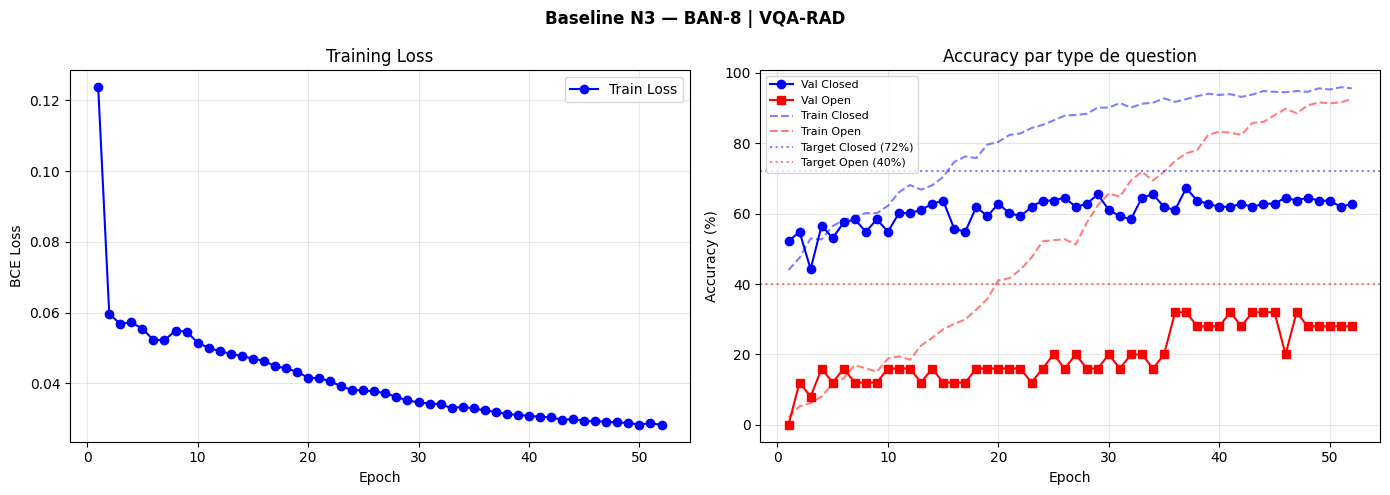

Courbes sauvegardées : learning_curves_n3_ban8.png


In [13]:
import matplotlib.pyplot as plt

epochs_range = [h['epoch'] for h in history]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(epochs_range, [h['loss'] for h in history], 'b-o', label='Train Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('BCE Loss')
axes[0].set_title('Training Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(epochs_range, [h['val_closed'] for h in history],  'b-o', label='Val Closed')
axes[1].plot(epochs_range, [h['val_open']   for h in history],  'r-s', label='Val Open')
axes[1].plot(epochs_range, [h['train_closed'] for h in history],'b--', alpha=0.5, label='Train Closed')
axes[1].plot(epochs_range, [h['train_open']   for h in history],'r--', alpha=0.5, label='Train Open')
axes[1].axhline(72, color='blue',  linestyle=':', alpha=0.5, label='Target Closed (72%)')
axes[1].axhline(40, color='red',   linestyle=':', alpha=0.5, label='Target Open (40%)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Accuracy par type de question')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Baseline N3 — BAN-8 | VQA-RAD', fontweight='bold')
plt.tight_layout()
plt.savefig('learning_curves_n3_ban8.png', dpi=150, bbox_inches='tight')
plt.show()
print('Courbes sauvegardées : learning_curves_n3_ban8.png')

## Part 14 — Évaluation finale sur le Test Set

Métriques CDC N3 : **Closed Acc., Open Acc., F1-macro, BLEU-1**

In [14]:
from sklearn.metrics import f1_score
from sacrebleu.metrics import BLEU

# ─── Charger le meilleur checkpoint ──────────────────────────────────────────
ck = torch.load('best_n3_ban8.pth', map_location=device)
model_eval = MedVQA_N3_BAN8(
    num_closed = ck['num_closed'],
    num_open   = ck['num_open'],
    ban_dim    = ck['ban_dim'],
).to(device)
model_eval.load_state_dict(ck['model_state_dict'])
model_eval.eval()
print(f"Checkpoint chargé — epoch {ck['epoch']+1} "
      f"| val_closed={ck['val_acc_closed']:.1f}% "
      f"| val_open={ck['val_acc_open']:.1f}%")

# ─── Inférence sur le test set ───────────────────────────────────────────────
all_preds_c, all_labels_c = [], []
all_preds_o, all_labels_o = [], []
hyps, refs = [], []

with torch.no_grad():
    for imgs, input_ids, attn_mask, ans_types, labels, _ in test_loader:
        imgs      = imgs.to(device)
        input_ids = input_ids.to(device)
        attn_mask = attn_mask.to(device)

        logits_c, logits_o, _ = model_eval(imgs, input_ids, attn_mask)

        mask_c = (ans_types == 0)
        mask_o = (ans_types == 1)

        if mask_c.any():
            preds_c = logits_c[mask_c].argmax(1).cpu().tolist()
            lbls_c  = labels[mask_c].tolist()
            all_preds_c.extend(preds_c)
            all_labels_c.extend(lbls_c)

        if mask_o.any():
            preds_o = logits_o[mask_o].argmax(1).cpu().tolist()
            lbls_o  = labels[mask_o].tolist()
            all_preds_o.extend(preds_o)
            all_labels_o.extend(lbls_o)
            hyps.extend([idx2open.get(p, '') for p in preds_o])
            refs.extend([idx2open.get(l, '') for l in lbls_o])

# ─── Métriques ────────────────────────────────────────────────────────────────
all_preds_c  = np.array(all_preds_c)
all_labels_c = np.array(all_labels_c)
all_preds_o  = np.array(all_preds_o)
all_labels_o = np.array(all_labels_o)

closed_acc = (all_preds_c == all_labels_c).mean() * 100 if len(all_labels_c) > 0 else 0.0
open_acc   = (all_preds_o == all_labels_o).mean() * 100 if len(all_labels_o) > 0 else 0.0

f1_closed  = f1_score(all_labels_c, all_preds_c, average='macro', zero_division=0)
f1_open    = f1_score(all_labels_o, all_preds_o, average='macro', zero_division=0)
f1_combined = (f1_closed + f1_open) / 2.0

# BLEU-1 sur les questions ouvertes
bleu_metric = BLEU(max_ngram_order=1)
bleu_score  = bleu_metric.corpus_score(hyps, [refs]).score / 100 if hyps else 0.0

# ─── Affichage ────────────────────────────────────────────────────────────────
print('\n' + '=' * 65)
print('  TEST RESULTS — Baseline N3 (BAN-8 | VQA-RAD)')
print('=' * 65)
print(f'  Closed Accuracy : {closed_acc:6.2f}%   [cible : 72-76%]')
print(f'  Open   Accuracy : {open_acc:6.2f}%   [cible : 40-45%]')
print(f'  F1-macro combiné: {f1_combined:.4f}   (closed={f1_closed:.3f} / open={f1_open:.3f})')
print(f'  BLEU-1          : {bleu_score:.4f}')
print(f'  Échantillons    : CLOSED={len(all_labels_c)} | OPEN={len(all_labels_o)}')
print('=' * 65)

# Verdict
if closed_acc >= 72 and open_acc >= 40:
    print('  ✅ Performances dans la cible CDC N3')
elif closed_acc >= 65:
    print('  ⚠️  Performances proches — vérifier hyperparamètres')
else:
    print('  ❌ Performances sous la cible — voir suggestions de debug')

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Checkpoint chargé — epoch 37 | val_closed=67.3% | val_open=32.0%

  TEST RESULTS — Baseline N3 (BAN-8 | VQA-RAD)
  Closed Accuracy :  57.35%   [cible : 72-76%]
  Open   Accuracy :  39.76%   [cible : 40-45%]
  F1-macro combiné: 0.1644   (closed=0.131 / open=0.198)
  BLEU-1          : 0.3456
  Échantillons    : CLOSED=272 | OPEN=83
  ❌ Performances sous la cible — voir suggestions de debug


## Part 15 — Analyse par type de question (question_type)

In [15]:
# Analyse détaillée par question_type (ABNORMALITY, MODALITY, ORGAN, etc.)
from collections import defaultdict

results_by_qtype = defaultdict(lambda: {'correct': 0, 'total': 0})

model_eval.eval()
with torch.no_grad():
    for imgs, input_ids, attn_mask, ans_types, labels, qtypes in test_loader:
        imgs      = imgs.to(device)
        input_ids = input_ids.to(device)
        attn_mask = attn_mask.to(device)

        logits_c, logits_o, _ = model_eval(imgs, input_ids, attn_mask)

        for i, (qtype, atype, label) in enumerate(zip(qtypes, ans_types, labels)):
            if atype == 0:
                pred = logits_c[i].argmax().item()
            else:
                pred = logits_o[i].argmax().item()
            correct = int(pred == label.item())
            results_by_qtype[qtype]['correct'] += correct
            results_by_qtype[qtype]['total']   += 1

print('\n  Accuracy par type de question :')
print(f"  {'Type':<20} {'Correct':>8} {'Total':>8} {'Acc (%)':>10}")
print('  ' + '-' * 50)
for qtype in sorted(results_by_qtype.keys()):
    r   = results_by_qtype[qtype]
    acc = 100 * r['correct'] / r['total'] if r['total'] > 0 else 0
    print(f"  {qtype:<20} {r['correct']:>8} {r['total']:>8} {acc:>10.1f}%")


  Accuracy par type de question :
  Type                  Correct    Total    Acc (%)
  --------------------------------------------------
  ABN                        21       46       45.7%
  ATTRIB                      2       16       12.5%
  ATTRIB, PRES                1        1      100.0%
  COLOR                       2        3       66.7%
  COUNT                       4        6       66.7%
  MODALITY                   14       24       58.3%
  ORGAN                       5        7       71.4%
  OTHER                       5       14       35.7%
  PLANE                      19       25       76.0%
  POS                        10       36       27.8%
  POS, PRES                   2        2      100.0%
  PRES                       81      131       61.8%
  PRES, ATTRIB                1        2       50.0%
  PRES, COLOR                 1        1      100.0%
  SIZE                       21       40       52.5%
  SIZE, PRES                  0        1        0.0%


## Part 16 — Visualisation des attention maps BAN-8

  Grid : 14×14 (196 tokens) | Têtes : 8


/tmp/ipykernel_6652/638514649.py:87: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6652/638514649.py:89: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(fname, dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


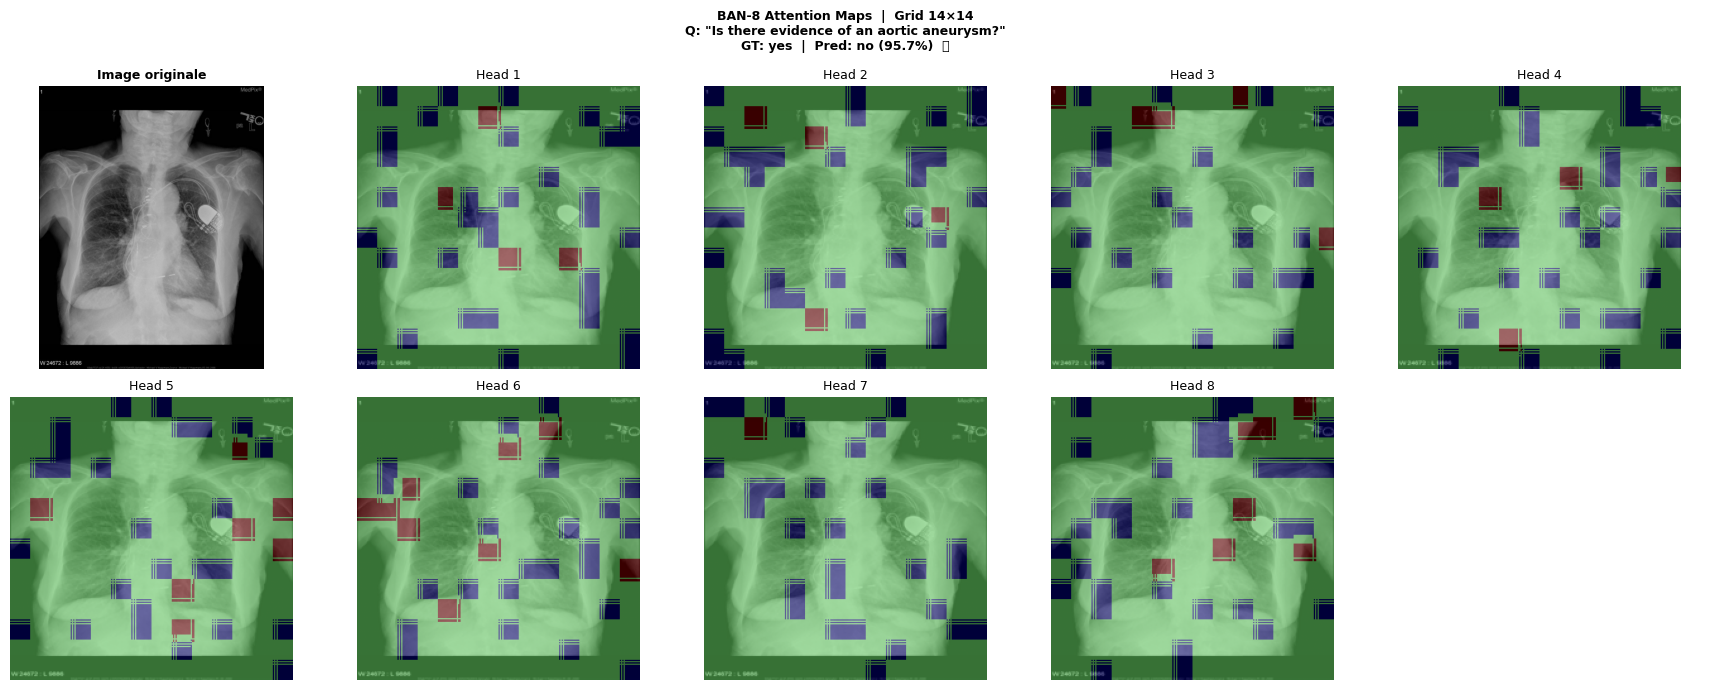

  GT: yes | Pred: no (95.7%) ❌
  Grid : 14×14 (196 tokens) | Têtes : 8


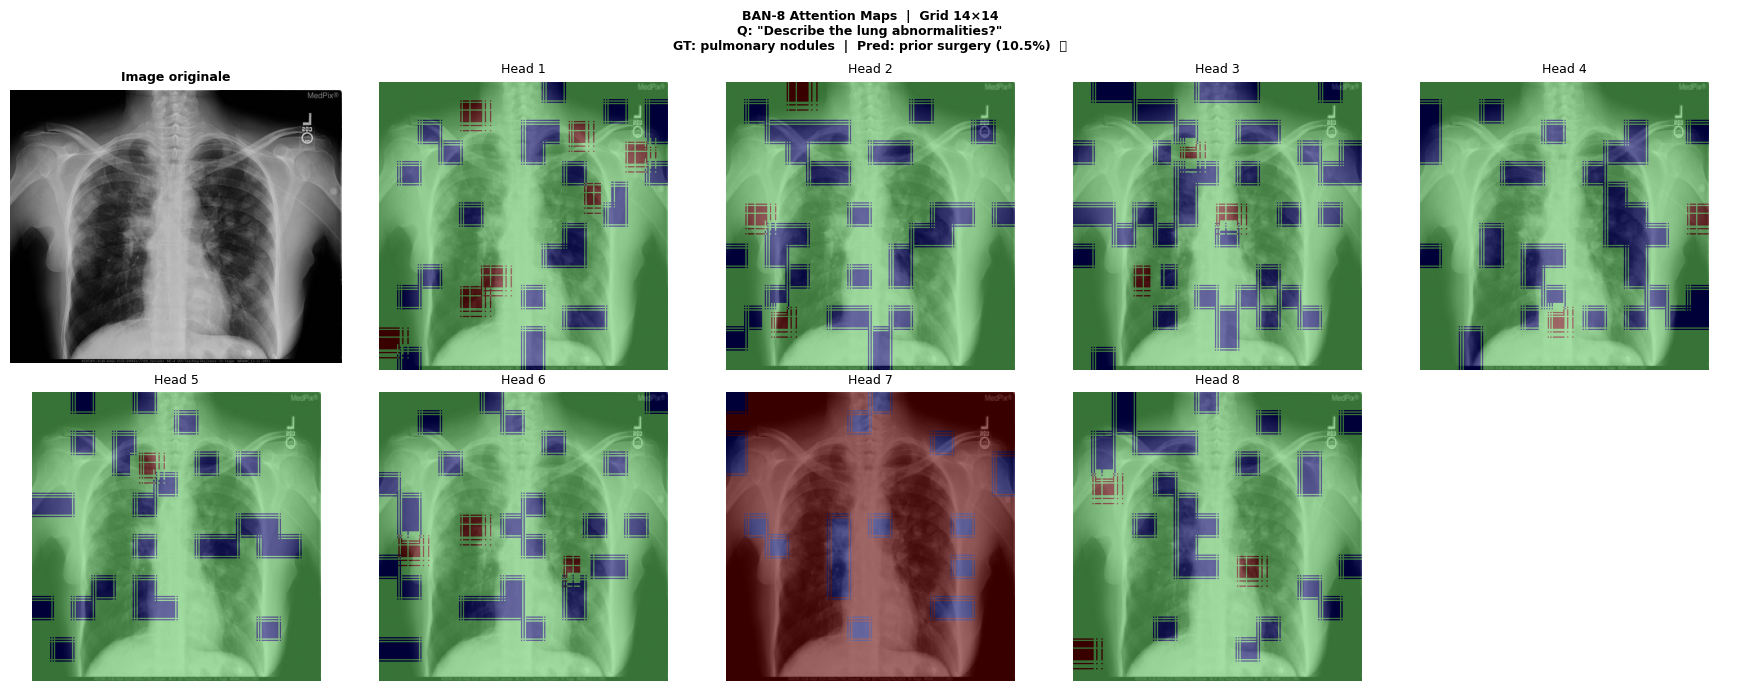

  GT: pulmonary nodules | Pred: prior surgery (10.5%) ❌


'prior surgery'

In [16]:
import matplotlib.pyplot as plt
import math

def visualize_ban_attention(model, sample, idx2closed, idx2open, image_dir=DATA_DIR):
    """
    Affiche les 8 cartes d'attention BAN-8 pour un échantillon.
    Le grid size est détecté automatiquement depuis la forme de attn_maps.

    CORRECTION : l'ancienne version hardcodait reshape(8, 14, 14)
    ce qui causait un ValueError si le grid était 28×28 (784 tokens).
    """
    model.eval()

    # ── Préparer l'image ─────────────────────────────────────────────────
    img_path   = os.path.join(image_dir, sample['image_name'])
    img_orig   = Image.open(img_path).convert('RGB')
    img_tensor = val_transform(img_orig).unsqueeze(0).to(device)

    # ── Tokeniser la question ─────────────────────────────────────────────
    tokens    = tokenizer([sample['question']], padding=True, truncation=True,
                          max_length=CFG['max_seq_len'], return_tensors='pt')
    input_ids = tokens['input_ids'].to(device)
    attn_mask = tokens['attention_mask'].to(device)

    # ── Forward pass ──────────────────────────────────────────────────────
    with torch.no_grad():
        logits_c, logits_o, attn_maps = model(img_tensor, input_ids, attn_mask)

    # ── Prédiction ────────────────────────────────────────────────────────
    is_closed = (sample['answer_type'] == 'CLOSED')
    if is_closed:
        pred_idx = logits_c[0].argmax().item()
        pred_ans = idx2closed.get(pred_idx, '?')
        conf     = torch.softmax(logits_c[0], dim=0)[pred_idx].item() * 100
    else:
        pred_idx = logits_o[0].argmax().item()
        pred_ans = idx2open.get(pred_idx, '?')
        conf     = torch.softmax(logits_o[0], dim=0)[pred_idx].item() * 100

    # ── Détecter le grid size automatiquement ────────────────────────────
    # attn_maps shape : (B, n_heads, Nv, Nq)
    n_heads = attn_maps.shape[1]
    Nv      = attn_maps.shape[2]          # nombre de tokens visuels
    grid_size = int(math.isqrt(Nv))
    assert grid_size * grid_size == Nv, f"Nv={Nv} n'est pas un carré parfait"
    print(f"  Grid : {grid_size}×{grid_size} ({Nv} tokens) | Têtes : {n_heads}")

    # attn_maps[0] : (n_heads, Nv, Nq) → moy. sur Nq → (n_heads, G, G)
    attn = attn_maps[0].mean(dim=-1).cpu().numpy()        # (n_heads, Nv)
    attn = attn.reshape(n_heads, grid_size, grid_size)     # (n_heads, G, G)

    # ── Figure ────────────────────────────────────────────────────────────
    ncols = 5
    nrows = math.ceil((n_heads + 1) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.5, nrows * 3.5))
    axes = axes.flatten()

    # Image originale (case 0)
    axes[0].imshow(img_orig)
    axes[0].set_title('Image originale', fontweight='bold', fontsize=9)
    axes[0].axis('off')

    # 8 têtes d'attention
    for h in range(n_heads):
        ax = axes[h + 1]
        # Upsampling grid_size×grid_size → 224×224
        heat = torch.tensor(attn[h]).unsqueeze(0).unsqueeze(0)
        heat = F.interpolate(heat, size=(224, 224), mode='bilinear', align_corners=False)
        heat = heat.squeeze().numpy()
        heat = (heat - heat.min()) / (heat.max() - heat.min() + 1e-8)
        ax.imshow(img_orig.resize((224, 224)))
        ax.imshow(heat, cmap='jet', alpha=0.45)
        ax.set_title(f'Head {h + 1}', fontsize=9)
        ax.axis('off')

    # Masquer les axes vides
    for idx in range(n_heads + 1, len(axes)):
        axes[idx].axis('off')

    correct = '✅' if pred_ans == sample['answer'] else '❌'
    plt.suptitle(
        f'BAN-{n_heads} Attention Maps  |  Grid {grid_size}×{grid_size}\n'
        f'Q: "{sample["question"]}"\n'
        f'GT: {sample["answer"]}  |  Pred: {pred_ans} ({conf:.1f}%)  {correct}',
        fontsize=9, fontweight='bold'
    )
    plt.tight_layout()
    fname = f'ban_attention_{sample["answer_type"].lower()}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'  GT: {sample["answer"]} | Pred: {pred_ans} ({conf:.1f}%) {correct}')
    return pred_ans


# Visualiser sur un exemple du test set
sample_closed = next(s for s in test_data if s['answer_type'] == 'CLOSED')
visualize_ban_attention(model_eval, sample_closed, idx2closed, idx2open)

sample_open = next(s for s in test_data if s['answer_type'] == 'OPEN')
visualize_ban_attention(model_eval, sample_open, idx2closed, idx2open)

## Part 17 — Inférence sur un exemple unique

In [17]:
def predict_single(image_path, question, model=model_eval,
                   answer_type_hint=None):
    """
    Prédit la réponse à une question clinique sur une image médicale.

    Args:
        image_path      : chemin vers l'image (DICOM converti en PNG/JPG)
        question        : question en langage naturel
        answer_type_hint: 'CLOSED' ou 'OPEN' (si None, détection heuristique)
    """
    model.eval()

    # Image
    img    = Image.open(image_path).convert('RGB')
    tensor = val_transform(img).unsqueeze(0).to(device)

    # Texte
    tokens    = tokenizer([question], padding=True, truncation=True,
                          max_length=CFG['max_seq_len'], return_tensors='pt')
    input_ids = tokens['input_ids'].to(device)
    attn_mask = tokens['attention_mask'].to(device)

    # Détection du type si non fourni
    if answer_type_hint is None:
        closed_starters = ('is ', 'are ', 'does ', 'do ', 'was ', 'were ',
                           'can ', 'has ', 'have ', 'did ', 'will ')
        is_closed = question.lower().startswith(closed_starters)
    else:
        is_closed = (answer_type_hint.upper() == 'CLOSED')

    with torch.no_grad():
        logits_c, logits_o, _ = model(tensor, input_ids, attn_mask)

    if is_closed:
        probs  = torch.softmax(logits_c[0], dim=0)
        idx    = probs.argmax().item()
        answer = idx2closed.get(idx, 'unknown')
    else:
        probs  = torch.softmax(logits_o[0], dim=0)
        idx    = probs.argmax().item()
        answer = idx2open.get(idx, 'unknown')

    conf  = probs[idx].item() * 100
    top3  = probs.topk(3)
    vocab = idx2closed if is_closed else idx2open

    print(f'  Question : {question}')
    print(f'  Type     : {"CLOSED" if is_closed else "OPEN"}')
    print(f'  Réponse  : {answer}  (confiance : {conf:.1f}%)')
    print(f'  Top-3    : ', end='')
    for i, (score, tidx) in enumerate(zip(top3.values.tolist(), top3.indices.tolist())):
        print(f'{vocab.get(tidx, "?")} ({score*100:.1f}%)', end='  ')
    print()
    return answer


# Test sur un exemple du dataset
sample = test_data[0]
img_path = os.path.join(DATA_DIR, sample['image_name'])
print(f'  Vrai label : {sample["answer"]} ({sample["answer_type"]})')
predict_single(img_path, sample['question'], answer_type_hint=sample['answer_type'])

  Vrai label : yes (CLOSED)
  Question : Is there evidence of an aortic aneurysm?
  Type     : CLOSED
  Réponse  : no  (confiance : 95.7%)
  Top-3    : no (95.7%)  superior (0.1%)  diffuse (0.1%)  


'no'

## Part 18 — Résumé & Tableau de résultats (format papier)

Ce tableau est prêt à être copié dans votre rapport / ablation study.

In [18]:
print('\n' + '=' * 70)
print('  TABLEAU RÉSULTATS — Format papier (ablation study)' )
print('=' * 70)
print(f'{"Baseline":<22} {"Closed Acc":>12} {"Open Acc":>10} {"F1-macro":>10} {"BLEU-1":>8}')
print('-' * 70)
print(f'{"N1 — Trivial":<22} {"~50%":>12} {"~10%":>10} {"—":>10} {"—":>8}')
print(f'{"N2 — CNN+LSTM":<22} {"58-62%":>12} {"20-25%":>10} {"à mesurer":>10} {"—":>8}')
print(f'{"N3 — BAN-8 ★":<22} {closed_acc:>11.2f}% {open_acc:>9.2f}% {f1_combined:>10.4f} {bleu_score:>8.4f}')
print(f'{"N4 — ViLBERT":<22} {"78-82%":>12} {"55-60%":>10} {"à mesurer":>10} {"à mesurer":>8}')
print(f'{"N5 — Fusionné ★":<22} {">82%":>12} {">60%":>10} {">0.75":>10} {">0.55":>8}')
print('=' * 70)
print('  ★ N3 = votre implémentation | N5 = cible finale du projet')
print()
print('  Config BAN-8 utilisée :')
print(f'    - Encodeur image : ResNet-50 grid 14×14 (pas global pooling)')
print(f'    - Encodeur texte : BERT-base-uncased (séquence complète)')
print(f'    - BAN            : {CFG["ban_heads"]} têtes × {CFG["ban_dim"]//CFG["ban_heads"]}D = {CFG["ban_dim"]}D')
print(f'    - Loss           : BCEWithLogitsLoss + soft labels (smooth={CFG["label_smooth"]})')
print(f'    - Params BAN     : ~{sum(p.numel() for p in model_eval.ban.parameters()):,}')


  TABLEAU RÉSULTATS — Format papier (ablation study)
Baseline                 Closed Acc   Open Acc   F1-macro   BLEU-1
----------------------------------------------------------------------
N1 — Trivial                   ~50%       ~10%          —        —
N2 — CNN+LSTM                58-62%     20-25%  à mesurer        —
N3 — BAN-8 ★                 57.35%     39.76%     0.1644   0.3456
N4 — ViLBERT                 78-82%     55-60%  à mesurer à mesurer
N5 — Fusionné ★                >82%       >60%      >0.75    >0.55
  ★ N3 = votre implémentation | N5 = cible finale du projet

  Config BAN-8 utilisée :
    - Encodeur image : ResNet-50 grid 14×14 (pas global pooling)
    - Encodeur texte : BERT-base-uncased (séquence complète)
    - BAN            : 8 têtes × 128D = 1024D
    - Loss           : BCEWithLogitsLoss + soft labels (smooth=0.2)
    - Params BAN     : ~3,146,752
